### Schematic Illustration: Generation and Redundancy of Spanning Deletion (* Allele)

**Purpose of the Figure**:
This figure aims to visually explain the biological origin of the **`*` (Star Allele / Spanning Deletion)** in VCF files and its logical significance in variant analysis, helping to understand why this allele is usually considered redundant.

**Problem Addressed and Core Logic**:
1.  **Phenomenon (Panel A)**:
    *   When an upstream deletion (e.g., Deletion in Sample 2 at POS 3) physically spans across a downstream variant site (POS 4), the DNA sequence at the downstream site effectively "does not exist".
2.  **Encoding (Panel B)**:
    *   After multiallelic decomposition (Normalization), the VCF generates a `*` allele at the downstream site (POS 4) as a placeholder indicating "this site has been deleted by an upstream deletion".
3.  **Conclusion (Panel C)**:
    *   **Record A** has already fully recorded this deletion event.
    *   The **`*`** in **Record B** is merely a marker pointing back to Record A.
    *   Therefore, when counting variants or performing association analysis, the information contained in the `*` allele is redundant (some software handles this automatically, but extra care is needed for custom statistics).

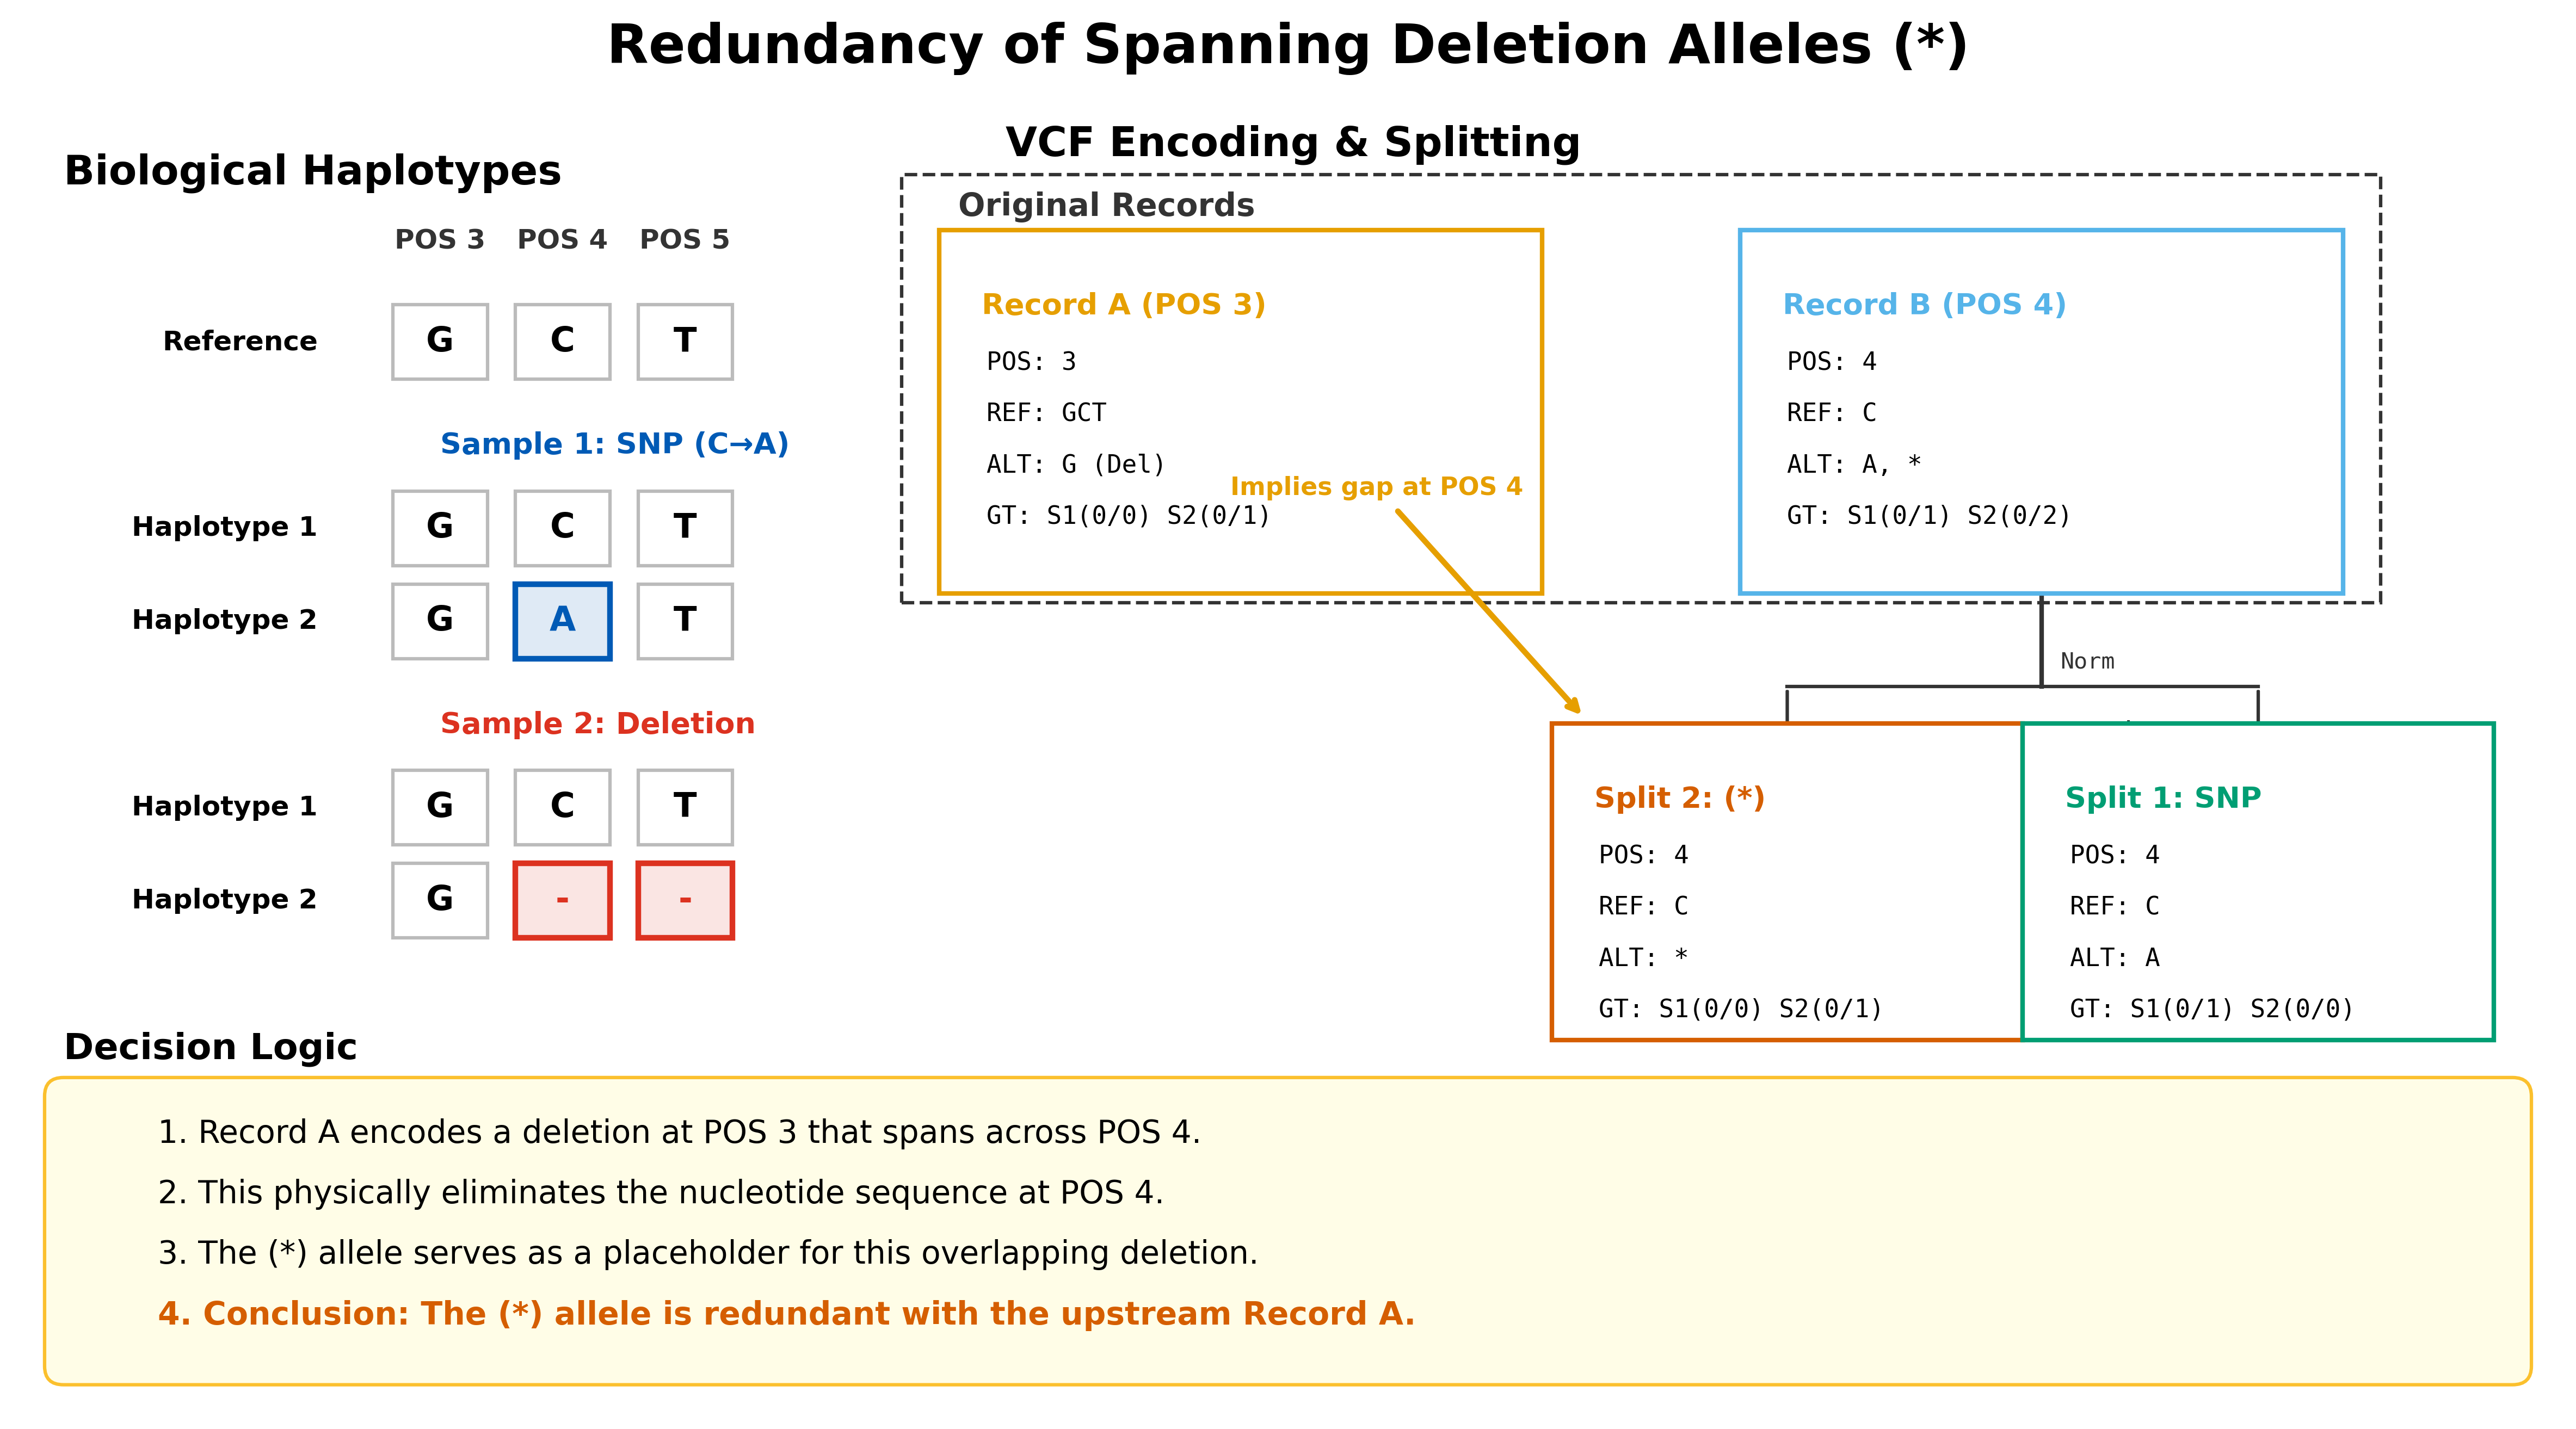

In [43]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Rectangle, Circle, PathPatch
from matplotlib.path import Path

# --- PPT / Presentation Style Setup ---
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Calibri', 'DejaVu Sans']
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.size'] = 14
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['lines.linewidth'] = 2

# Figure setup
fig, ax = plt.subplots(figsize=(16, 9), dpi=300) 
ax.set_xlim(0, 27)
ax.set_ylim(0, 15)
ax.axis('off')

# --- Colors ---
COLORS = {
    'text_main': '#000000',
    'text_sub': '#333333',
    's1_blue': '#005AB5',
    's2_red': '#DC3220',
    'rec_orange': '#E69F00', 
    'rec_blue': '#56B4E9',   
    'keep_green': '#009E73', 
    'del_red': '#D55E00',
    'box_fill': '#FFFFFF',
    'shadow': '#DDDDDD'
}

# --- Utilities ---
def draw_card(x, y, w, h, title, content, color):
    # Shadow removed as requested
    
    # Main Box (Square corners via boxstyle='square')
    # Using 'square,pad=0.2' gives sharp corners
    box = FancyBboxPatch((x, y), w, h, boxstyle="square,pad=0.2",
                         linewidth=2.0, edgecolor=color, facecolor=COLORS['box_fill'], zorder=10)
    ax.add_patch(box)
    
    # Title
    ax.text(x+0.25, y+h-0.7, title, fontsize=13, fontweight='bold', color=color, zorder=11)
    
    # Content
    start_y = y + h - 1.3
    line_spacing = 0.55
    
    for i, line in enumerate(content):
        ax.text(x+0.3, start_y - i*line_spacing, line, fontsize=11, family='monospace', color=COLORS['text_main'], zorder=11)
    
    return x+w/2, y+h, x+w/2, y 

def draw_hap_row(label, bases, y_pos, highlight_idx=None, highlight_col='blue'):
    ax.text(3.2, y_pos, label, ha='right', va='center', fontsize=12, 
            fontfamily='sans-serif', color=COLORS['text_main'], fontweight='bold')
    
    base_spacing = 1.3
    start_x = 4.5
    for i, b in enumerate(bases):
        x = start_x + i * base_spacing
        bg = 'white'
        fc = 'black'
        ec = '#BBBBBB'
        lw = 1.5
        if highlight_idx is not None and i in highlight_idx:
            bg = highlight_col + '20' 
            fc = highlight_col
            ec = highlight_col
            lw = 2.5
            
        rect = Rectangle((x-0.5, y_pos-0.4), 1.0, 0.8, facecolor=bg, 
                        edgecolor=ec, linewidth=lw, zorder=5)
        ax.add_patch(rect)
        ax.text(x, y_pos, b, ha='center', va='center', fontweight='bold', 
                color=fc, fontsize=15, zorder=6)

# --- FIGURE HEADER ---
ax.text(13.5, 14.5, "Redundancy of Spanning Deletion Alleles (*)", 
        fontsize=24, fontweight='bold', ha='center', color='black')
# Removed underline as requested
# ax.plot([1, 26], [14.0, 14.0], color='#444444', linewidth=1.0)

# ==========================================
# PANEL A: Biological Haplotypes (Left)
# ==========================================
ax.text(0.5, 13.2, "Biological Haplotypes", 
        fontsize=18, fontweight='bold', color=COLORS['text_main'])

# Column Headers
for i, t in enumerate(["POS 3", "POS 4", "POS 5"]):
    ax.text(4.5 + i*1.3, 12.5, t, ha='center', fontsize=12, 
            fontweight='bold', color=COLORS['text_sub'])

# Reference
draw_hap_row("Reference", ['G', 'C', 'T'], 11.5)

# Sample 1
ax.text(4.5, 10.3, "Sample 1: SNP (C→A)", fontsize=13, ha='left',
        color=COLORS['s1_blue'], fontweight='bold')
draw_hap_row("Haplotype 1", ['G', 'C', 'T'], 9.5)
draw_hap_row("Haplotype 2", ['G', 'A', 'T'], 8.5, [1], COLORS['s1_blue'])

# Sample 2  
ax.text(4.5, 7.3, "Sample 2: Deletion", fontsize=13, ha='left',
        color=COLORS['s2_red'], fontweight='bold')
draw_hap_row("Haplotype 1", ['G', 'C', 'T'], 6.5)
draw_hap_row("Haplotype 2", ['G', '-', '-'], 5.5, [1, 2], COLORS['s2_red'])


# ==========================================
# PANEL B: VCF Encoding (Right)
# ==========================================
ax.text(10.5, 13.5, "VCF Encoding & Splitting", 
        fontsize=18, fontweight='bold', color=COLORS['text_main'])

# Group Label for "Original Records"
grp_x, grp_y, grp_w, grp_h = 9.5, 8.8, 15.5, 4.4 
grp_box = FancyBboxPatch((grp_x, grp_y), grp_w, grp_h, boxstyle="square,pad=0.1",
                         linewidth=1.5, edgecolor=COLORS['text_sub'], facecolor='none', linestyle='--', zorder=5)
ax.add_patch(grp_box)
# Moved label down: (grp_h - 0.4) instead of grp_h
ax.text(grp_x + 0.5, grp_y + grp_h - 0.25, "Original Records", fontsize=14, 
        fontweight='bold', color=COLORS['text_sub'], va='center', ha='left', 
        bbox=dict(facecolor='white', edgecolor='none', pad=2))

REC_Y = 9.0
REC_H = 3.5

# Record A (Left)
# Modified GT to include S1 and S2
REC_A_X = 10.0
REC_A_W = 6.0
pos3_cx, pos3_ct, pos3_cx_b, pos3_cb = draw_card(REC_A_X, REC_Y, REC_A_W, REC_H, 
                                                  "Record A (POS 3)", 
                                                  ["POS: 3", "REF: GCT", 
                                                   "ALT: G (Del)", 
                                                   "GT: S1(0/0) S2(0/1)"], 
                                                  COLORS['rec_orange'])

# Record B (Right)
# Modified GT to include S1 and S2
REC_B_X = 18.5
REC_B_W = 6.0
pos4_cx, pos4_ct, pos4_cx_b, pos4_cb = draw_card(REC_B_X, REC_Y, REC_B_W, REC_H, 
                                                  "Record B (POS 4)", 
                                                  ["POS: 4", "REF: C", 
                                                   "ALT: A, *", 
                                                   "GT: S1(0/1) S2(0/2)"], 
                                                  COLORS['rec_blue'])

# Decomposed Section Label
ax.text(21.5, 7.2, "Decomposed:", fontsize=13, color=COLORS['text_sub'], ha='center')

SPLIT_Y = 4.2
SPLIT_H = 3.0
SPLIT_W = 4.6

# Split 2 (Spanning)
# Modified GT to include S1 and S2
SPLIT2_X = 16.5
split2_cx, split2_ct, split2_cx_b, split2_cb = draw_card(SPLIT2_X, SPLIT_Y, SPLIT_W, SPLIT_H, 
                                                          "Split 2: (*)", 
                                                          ["POS: 4", "REF: C", 
                                                           "ALT: *", 
                                                           "GT: S1(0/0) S2(0/1)"], 
                                                          COLORS['del_red'])

# Split 1 (SNP)
# Modified GT to include S1 and S2
SPLIT1_X = 21.5
split1_cx, split1_ct, split1_cx_b, split1_cb = draw_card(SPLIT1_X, SPLIT_Y, SPLIT_W, SPLIT_H, 
                                                          "Split 1: SNP", 
                                                          ["POS: 4", "REF: C", 
                                                           "ALT: A", 
                                                           "GT: S1(0/1) S2(0/0)"], 
                                                          COLORS['keep_green'])

# --- CONNECTIONS ---

# 1. Normalization Flow: Rec B -> Split 1 & 2
ax.plot([pos4_cx_b, pos4_cx_b], [pos4_cb, 7.8], color=COLORS['text_sub'], lw=2, zorder=5) 
ax.text(pos4_cx_b + 0.2, 8.0, "Norm", fontsize=10, family='monospace', color=COLORS['text_sub'], ha='left')

ax.plot([split2_cx, split1_cx], [7.8, 7.8], color=COLORS['text_sub'], lw=1.5, zorder=5)

ax.add_patch(FancyArrowPatch((split2_cx, 7.8), (split2_cx, SPLIT_Y+SPLIT_H), 
                            arrowstyle='simple,tail_width=0.5,head_width=4,head_length=4', 
                            color=COLORS['text_sub'], zorder=5))

ax.add_patch(FancyArrowPatch((split1_cx, 7.8), (split1_cx, SPLIT_Y+SPLIT_H), 
                            arrowstyle='simple,tail_width=0.5,head_width=4,head_length=4', 
                            color=COLORS['text_sub'], zorder=5))


# 2. Logic Flow: Rec A -> Split 2
conn_start = (REC_A_X + REC_A_W, REC_Y + 0.8) 
conn_end = (SPLIT2_X + 0.2, SPLIT_Y + SPLIT_H + 0.2) 

ax.annotate("Implies gap at POS 4", 
            xy=conn_end, xycoords='data',
            xytext=conn_start, textcoords='data',
            arrowprops=dict(arrowstyle="->",
                            color=COLORS['rec_orange'],
                            lw=2.5,
                            shrinkA=5, shrinkB=5),
            fontsize=11, color=COLORS['rec_orange'], fontweight='bold', 
            ha='right', va='bottom', zorder=12,
            bbox=dict(boxstyle='square,pad=0.1', facecolor='white', edgecolor='none', alpha=0.7))


# ==========================================
# PANEL C: Logic (Bottom)
# ==========================================
panel_c_y = 0.5
panel_c_h = 2.9

ax.text(0.5, 3.8, "Decision Logic", fontsize=16, fontweight='bold', color=COLORS['text_main'])

proof_box = FancyBboxPatch((0.5, panel_c_y), 26.0, panel_c_h, boxstyle="round,pad=0.2", 
                          facecolor='#FFFDE7', edgecolor='#FBC02D', 
                          linewidth=1.5, zorder=1)
ax.add_patch(proof_box)

line_spacing = 0.65
start_text_y = panel_c_y + panel_c_h - 0.5

ax.text(1.5, start_text_y, "1. Record A encodes a deletion at POS 3 that spans across POS 4.", 
        fontsize=14, color=COLORS['text_main'])
ax.text(1.5, start_text_y - line_spacing, "2. This physically eliminates the nucleotide sequence at POS 4.", 
        fontsize=14, color=COLORS['text_main'])
ax.text(1.5, start_text_y - 2*line_spacing, "3. The (*) allele serves as a placeholder for this overlapping deletion.", 
        fontsize=14, color=COLORS['text_main'])
ax.text(1.5, start_text_y - 3*line_spacing, "4. Conclusion: The (*) allele is redundant with the upstream Record A.", 
        fontsize=14, fontweight='bold', color=COLORS['del_red'])

plt.tight_layout()
plt.show()